0) Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch, VerticalPitch


1) Carga de datos

In [2]:
DATA_PATH = "../data/processed/events.parquet"  # ajusta

events = pd.read_parquet(DATA_PATH) if DATA_PATH.endswith(".parquet") else pd.read_csv(DATA_PATH)
events.head()


,match_id,event_id,index,period,timestamp,minute,second,type,possession,possession_team,...,dribble_no_touch,shot_outcome,shot_statsbomb_xg,shot_body_part,shot_type,shot_technique,shot_first_time,shot_one_on_one,shot_open_goal,shot_aerial_won
0,3930158,f2207d37-beed-4073-84a5-f9d696e2afdd,1,1,00:00:00.000,0,0,Starting XI,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,3930158,43e494fe-4871-4b2a-a509-a325c17a5e3f,2,1,00:00:00.000,0,0,Starting XI,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,3930158,d9de8fe7-3122-4067-a1c2-a742c7edb2b8,3,1,00:00:00.000,0,0,Half Start,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,3930158,455f819f-3926-4ed4-a0e9-4e9e4d0bf95a,4,1,00:00:00.000,0,0,Half Start,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,3930158,df6f6fb7-f0b0-4561-9171-f4172f5e97e7,5,1,00:00:01.191,0,1,Pass,2,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None


2) Normalización mínima (type/team/player + x,y)

In [3]:
def _unpack_xy(series, idx):
    return series.apply(lambda v: v[idx] if isinstance(v, (list, tuple)) and len(v) > idx else np.nan)

# type
if "type" not in events.columns and "type.name" in events.columns:
    events["type"] = events["type.name"]
elif "type.name" in events.columns:
    events["type"] = events["type.name"]

# team / player
if "team" not in events.columns and "team.name" in events.columns:
    events["team"] = events["team.name"]
if "player" not in events.columns and "player.name" in events.columns:
    events["player"] = events["player.name"]

# coords
if "location" in events.columns:
    events["x"] = _unpack_xy(events["location"], 0)
    events["y"] = _unpack_xy(events["location"], 1)
elif not {"x","y"}.issubset(events.columns):
    raise ValueError("No encuentro 'location' ni columnas 'x','y'. Ajusta el mapeo.")

events[["type","team","player","x","y"]].head()


,type,team,player,x,y
0,Starting XI,Germany,NaN,NaN,NaN
1,Starting XI,Scotland,NaN,NaN,NaN
2,Half Start,Germany,NaN,NaN,NaN
3,Half Start,Scotland,NaN,NaN,NaN
4,Pass,Germany,Kai Havertz,61.0,40.1


3) Filtrar Ball Recovery + columnas útiles

En StatsBomb suele existir:

ball_recovery.recovery_failure (bool) en algunos dumps

ball_recovery.offensive (bool) en algunos dumps

ball_recovery.location no: la ubicación está en location

under_pressure (bool) a nivel de evento en muchos casos

In [4]:
recoveries = events[events["type"].eq("Ball Recovery")].copy()

# flags típicas (si no existen, se crean como NaN/False)
if "under_pressure" not in recoveries.columns:
    recoveries["under_pressure"] = False

# algunos datasets usan ball_recovery.recovery_failure
if "ball_recovery.recovery_failure" not in recoveries.columns:
    recoveries["ball_recovery.recovery_failure"] = np.nan

# algunos datasets tienen ball_recovery.offensive
if "ball_recovery.offensive" not in recoveries.columns:
    recoveries["ball_recovery.offensive"] = np.nan

recoveries[["team","player","x","y","under_pressure","ball_recovery.recovery_failure","ball_recovery.offensive"]].head()


,team,player,x,y,under_pressure,ball_recovery.recovery_failure,ball_recovery.offensive
11,Scotland,Callum McGregor,21.3,36.3,None,NaN,NaN
12,Scotland,Jack Hendry,17.3,33.7,None,NaN,NaN
20,Germany,Jonathan Tah,56.8,41.9,None,NaN,NaN
85,Germany,Florian Wirtz,68.6,3.8,None,NaN,NaN
144,Scotland,Ryan Christie,42.4,38.9,None,NaN,NaN


4) Helpers de plotting

In [5]:
def draw_pitch(title=None, vertical=False):
    pitch = VerticalPitch(pitch_type="statsbomb", line_zorder=2) if vertical else Pitch(pitch_type="statsbomb", line_zorder=2)
    fig, ax = pitch.draw(figsize=(10, 7))
    if title:
        fig.suptitle(title, fontsize=14)
    return pitch, fig, ax

def plot_recoveries(df, title, vertical=False, s=40, alpha=0.7):
    pitch, fig, ax = draw_pitch(title=title, vertical=vertical)
    pitch.scatter(df["x"], df["y"], ax=ax, s=s, alpha=alpha)
    return fig, ax


5) Mapa de recoveries por equipo (todas)

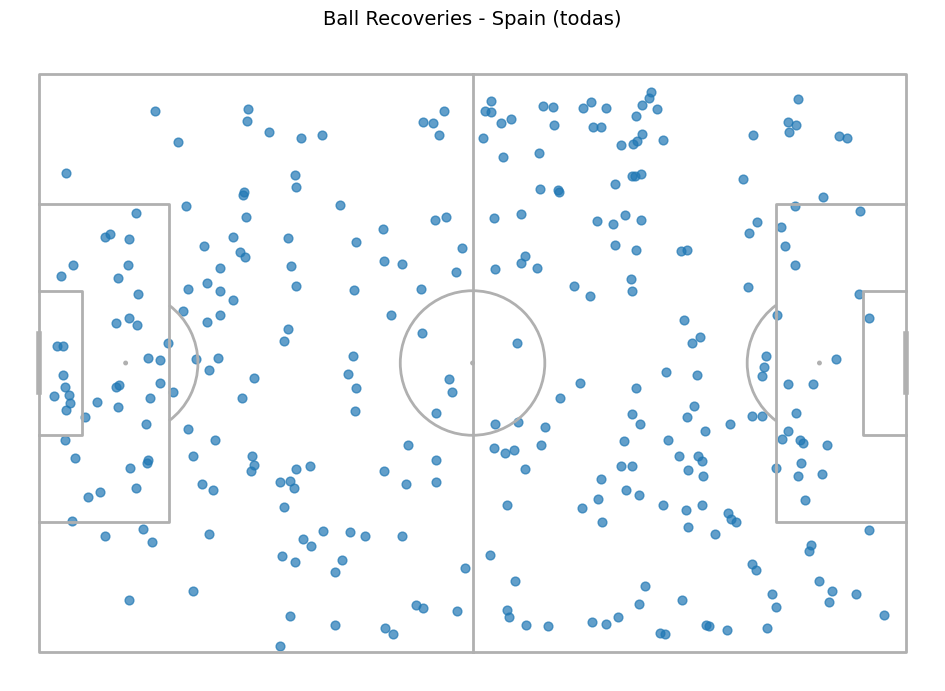

In [6]:
TEAM = recoveries["team"].dropna().value_counts().index[0]
team_rec = recoveries[recoveries["team"].eq(TEAM)]

fig, ax = plot_recoveries(team_rec, title=f"Ball Recoveries - {TEAM} (todas)")
plt.show()


6) Top jugadores (y mapa del top)

In [7]:
TEAM = recoveries["team"].dropna().value_counts().index[0]
team_rec = recoveries[recoveries["team"].eq(TEAM)]

top_players = team_rec["player"].value_counts().head(10)
top_players


player
Fabián Ruiz Peña               39
Rodrigo Hernández Cascante     28
Nicholas Williams Arthuer      25
Unai Simón Mendibil            25
Daniel Carvajal Ramos          23
Lamine Yamal Nasraoui Ebana    22
Daniel Olmo Carvajal           19
Mikel Merino Zazón             17
Marc Cucurella Saseta          16
Álvaro Borja Morata Martín     14
Name: count, dtype: int64

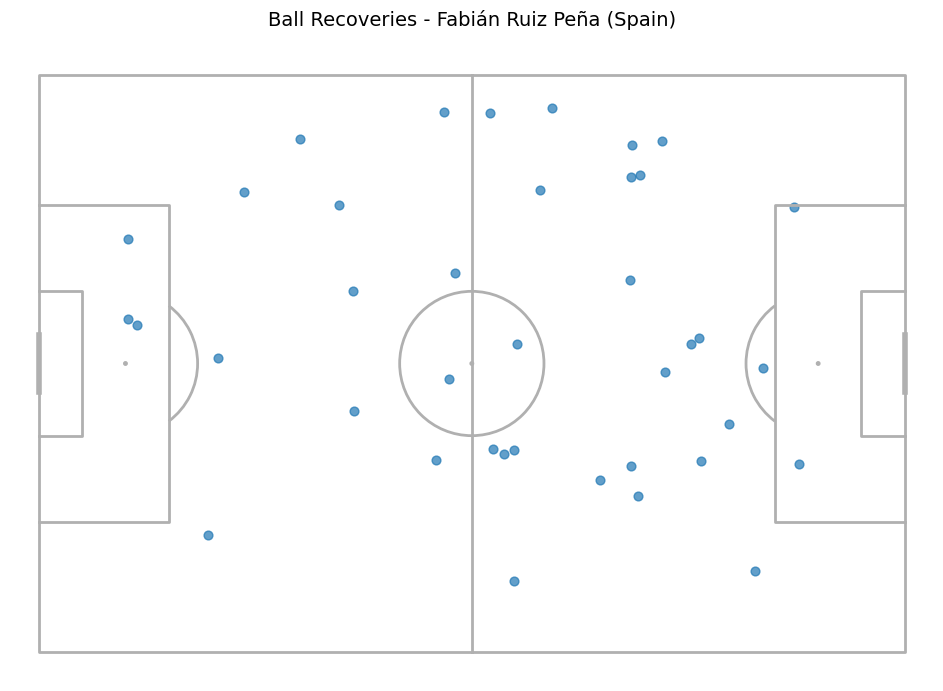

In [8]:
PLAYER = top_players.index[0]
player_rec = team_rec[team_rec["player"].eq(PLAYER)]

fig, ax = plot_recoveries(player_rec, title=f"Ball Recoveries - {PLAYER} ({TEAM})")
plt.show()


7) Heatmap de recoveries (zonas de recuperación)

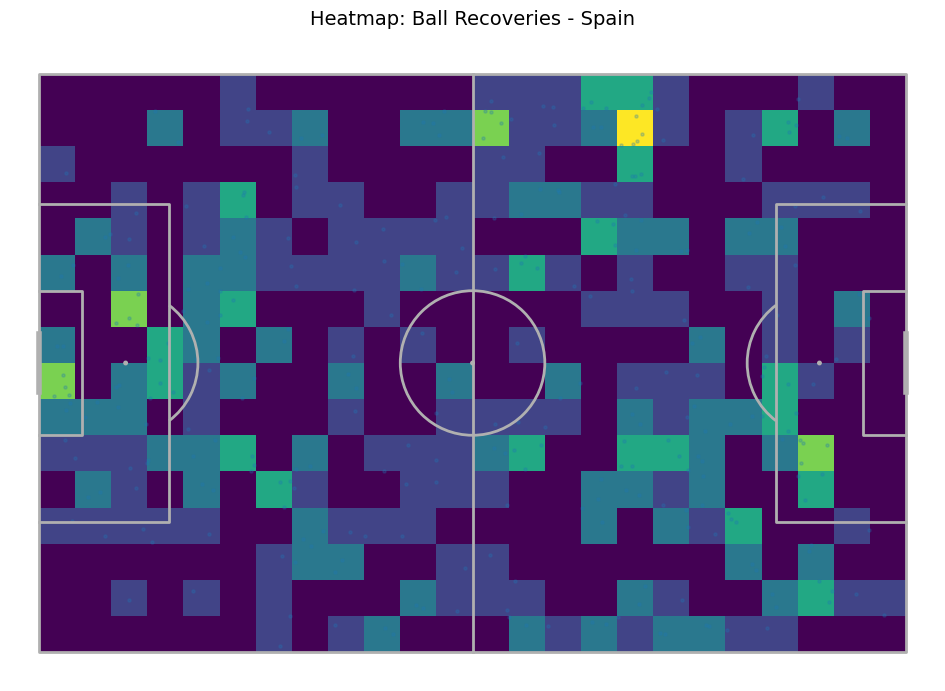

In [9]:
TEAM = recoveries["team"].dropna().value_counts().index[0]
team_rec = recoveries[recoveries["team"].eq(TEAM)]

pitch, fig, ax = draw_pitch(title=f"Heatmap: Ball Recoveries - {TEAM}")

bin_stat = pitch.bin_statistic(team_rec["x"], team_rec["y"], statistic="count", bins=(24, 16))
pitch.heatmap(bin_stat, ax=ax)
pitch.scatter(team_rec["x"], team_rec["y"], ax=ax, s=5, alpha=0.25)

plt.show()


8) Recoveries en presión (under_pressure)

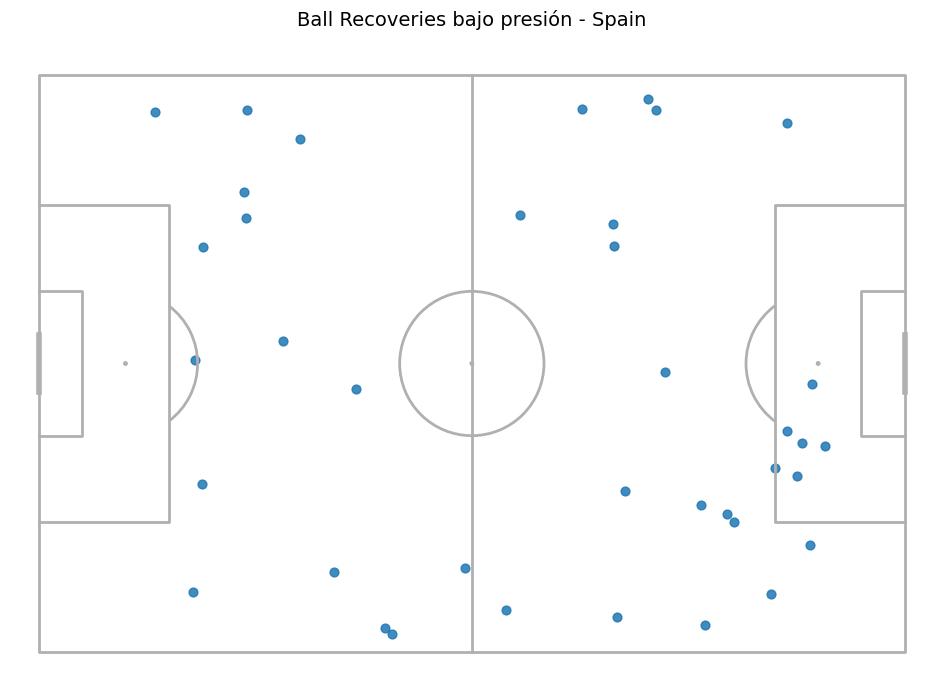

Spain: 38/312 recoveries bajo presión (12.2%)


In [10]:
TEAM = recoveries["team"].dropna().value_counts().index[0]
team_rec = recoveries[recoveries["team"].eq(TEAM)]

press_rec = team_rec[team_rec["under_pressure"].astype(bool)]

fig, ax = plot_recoveries(press_rec, title=f"Ball Recoveries bajo presión - {TEAM}", alpha=0.85)
plt.show()

print(f"{TEAM}: {len(press_rec)}/{len(team_rec)} recoveries bajo presión ({len(press_rec)/len(team_rec):.1%})")


9) Recoveries “altas” (en último tercio rival)

En StatsBomb, el tercio ofensivo suele ser x >= 80.

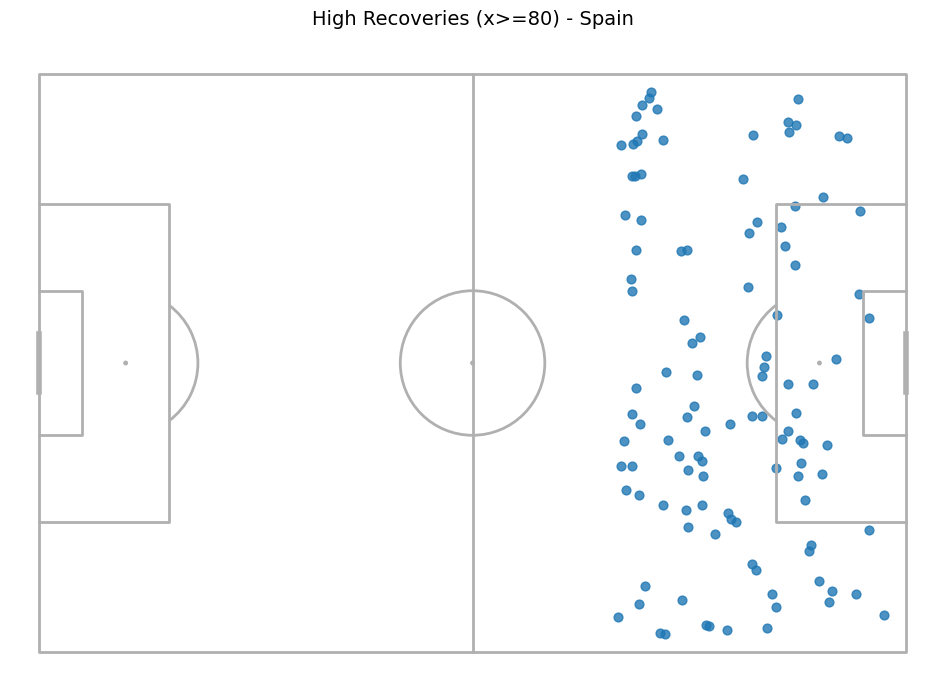

player
Fabián Ruiz Peña               16
Lamine Yamal Nasraoui Ebana    14
Nicholas Williams Arthuer      13
Rodrigo Hernández Cascante     10
Pedro González López            9
Daniel Carvajal Ramos           8
Daniel Olmo Carvajal            8
Álvaro Borja Morata Martín      7
Mikel Merino Zazón              6
Marc Cucurella Saseta           5
Name: count, dtype: int64

In [11]:
TEAM = recoveries["team"].dropna().value_counts().index[0]
team_rec = recoveries[recoveries["team"].eq(TEAM)]

high_rec = team_rec[team_rec["x"] >= 80]

fig, ax = plot_recoveries(high_rec, title=f"High Recoveries (x>=80) - {TEAM}", alpha=0.8)
plt.show()

high_rec["player"].value_counts().head(10)


10) Recoveries peligrosas (cerca del área rival)

Aproximación del área rival en StatsBomb:

x >= 102

y entre 18 y 62

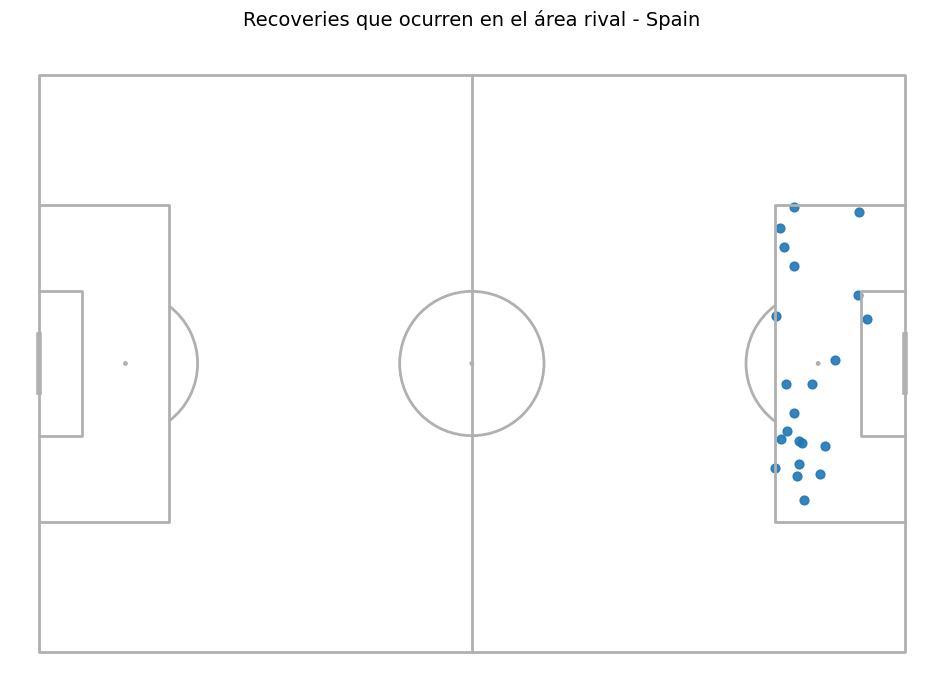

,player,x,y,minute,second,period
6954,Pedro González López,105.1,55.6,4,8,1
52138,Álvaro Borja Morata Martín,107.1,42.9,23,24,1
53219,Pedro González López,106.0,58.9,50,24,2
53284,Fabián Ruiz Peña,104.6,18.3,51,59,2
53288,Nicholas Williams Arthuer,103.3,23.8,52,4,2
78244,Daniel Olmo Carvajal,105.3,50.7,36,8,1
78396,Mikel Merino Zazón,102.1,33.4,40,8,1
79346,Daniel Olmo Carvajal,103.6,42.9,59,3,2
79717,Mikel Merino Zazón,102.7,21.2,70,15,2
79790,Fermin Lopez Marin,108.3,55.3,72,18,2


In [12]:
TEAM = recoveries["team"].dropna().value_counts().index[0]
team_rec = recoveries[recoveries["team"].eq(TEAM)]

danger = team_rec[(team_rec["x"] >= 102) & (team_rec["y"].between(18, 62))]

fig, ax = plot_recoveries(danger, title=f"Recoveries que ocurren en el área rival - {TEAM}", alpha=0.9)
plt.show()

danger[["player","x","y","minute","second","period"]].head(15)


11) Tabla resumen

In [13]:
TEAM = recoveries["team"].dropna().value_counts().index[0]
team_rec = recoveries[recoveries["team"].eq(TEAM)].copy()

summary = (
    team_rec.groupby("player")
    .agg(
        recoveries=("type","size"),
        under_pressure=("under_pressure", lambda s: int(pd.Series(s).astype(bool).sum())),
        high=("x", lambda s: int((s >= 80).sum())),
        box=("x", lambda s: int((team_rec.loc[s.index, "x"] >= 102).sum()))  # approx, simple
    )
    .sort_values(["recoveries","high"], ascending=False)
)

summary.head(15)


,recoveries,under_pressure,high,box
player,,,,
Fabián Ruiz Peña,39,3,16,2
Rodrigo Hernández Cascante,28,5,10,0
Nicholas Williams Arthuer,25,6,13,7
Unai Simón Mendibil,25,0,0,0
Daniel Carvajal Ramos,23,2,8,2
Lamine Yamal Nasraoui Ebana,22,5,14,5
Daniel Olmo Carvajal,19,6,8,7
Mikel Merino Zazón,17,3,6,3
Marc Cucurella Saseta,16,0,5,0
